# Model library

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class HNN(nn.Module):
    def __init__(self, n, d):
        super(HNN, self).__init__()
        self.n = n
        self.d = d
        self.half = n*d
        hidden_dim = 200

        layers = [nn.Linear(2 * n * d, hidden_dim), nn.Tanh()]
        for _ in range(2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class BaselineNN(nn.Module):
    def __init__(self, n, d):
        super(BaselineNN, self).__init__()
        self.n = n
        self.d = d
        self.half = n*d
        hidden_dim = 200

        layers = [nn.Linear(2 * n * d, hidden_dim), nn.Tanh()]
        for _ in range(2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 2 * n))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)



def hnn_loss(model, x, dx_target):
    x = x.requires_grad_(True)
    H = model.forward(x).sum()
    grad = torch.autograd.grad(H, x, create_graph=True)[0]
    h = model.half
    # dq/dt = dH/dp, dp/dt = -dH/dq
    dx_pred = torch.cat([grad[:, h:], -grad[:, :h]], dim=1)
    return F.mse_loss(dx_pred, dx_target)


def baseline_loss(model, x, dx_target):
    return F.mse_loss(model.forward(x), dx_target)

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

TTYPE = torch.float32

# Simple harmonic oscillator

In [3]:
def generate_mass_spring_data(n_traj=25, n_obs=30, energy_range=(0.2, 1.0),
                              noise_std=0, seed=42):
    rng = np.random.default_rng(seed)
    w = 1.0
    energies = np.linspace(energy_range[0], energy_range[1], n_traj)
    phases = rng.uniform(0, 2 * np.pi, n_traj)
    radii = np.sqrt(2 * energies)
    A = radii * np.sin(phases)
    B = radii * np.cos(phases)

    t = np.linspace(0, 2 * np.pi, n_obs)
    s, c = np.sin(w * t), np.cos(w * t)
    q = np.outer(A, s) + np.outer(B, c)
    p = w * (np.outer(A, c) - np.outer(B, s))
    dq = p.copy()
    dp = -q.copy()

    q += rng.normal(0, noise_std, q.shape)
    p += rng.normal(0, noise_std, p.shape)

    X = np.stack([q, p], axis=-1).reshape(-1, 2)
    dq = dq.reshape(-1, 1)
    dp = dp.reshape(-1, 1)
    return (torch.tensor(X, dtype=TTYPE),
            torch.tensor(dq, dtype=TTYPE),
            torch.tensor(dp, dtype=TTYPE))


QP, DQ, DP = generate_mass_spring_data()

DQP = torch.hstack((DQ, DP))

In [4]:
indx = np.random.permutation(len(QP))
train_indx = indx[:int(len(indx)*0.8)]
test_indx = indx[int(len(indx)*0.8):]

hnn_model = HNN(1, 1)
hnn_optim = torch.optim.Adam(hnn_model.parameters(), lr = 1e-3)

baseline_model = BaselineNN(1,1)
baseline_optim = torch.optim.Adam(baseline_model.parameters(), lr = 1e-3)


for step in range(2000):
    QP = QP.requires_grad_(True)
    hnn_optim.zero_grad()
    baseline_optim.zero_grad()
    hnn_L = hnn_loss(hnn_model, QP[train_indx], DQP[train_indx])
    baseline_L = baseline_loss(baseline_model, QP[train_indx], DQP[train_indx])
    hnn_L.backward()
    hnn_optim.step()
    baseline_L.backward()
    baseline_optim.step()


In [5]:
hnn_model.eval()
baseline_loss(baseline_model, QP[test_indx], DQP[test_indx])

tensor(6.5309e-06, grad_fn=<MseLossBackward0>)

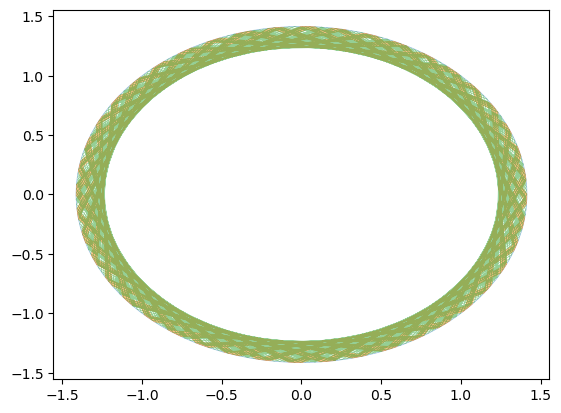

In [6]:
coords = generate_mass_spring_data(1, 100, (1,1))[0].T

def integrate_learned(model, y0, t_span, n_points=500, rtol=1e-9, atol=1e-9):
    h = model.half
    is_hnn = isinstance(model, HNN)

    def dydt(t, y_np):
        state = torch.tensor(y_np, dtype=torch.float32).unsqueeze(0)
        if is_hnn:
            state = state.requires_grad_(True)
            H = model.forward(state).sum()
            grad = torch.autograd.grad(H, state)[0][0]
            return torch.cat([grad[h:], -grad[:h]]).detach().numpy()
        else:
            with torch.no_grad():
                return model.forward(state)[0].numpy()

    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    sol = solve_ivp(dydt, t_span, y0, t_eval=t_eval, method='RK45',
                    rtol=rtol, atol=atol)
    return sol.t, sol.y.T

_, y_hnn = integrate_learned(hnn_model, coords[:,0], (0,500))
_, y_baseline = integrate_learned(baseline_model, coords[:,0], (0,500))

plt.plot(*coords, lw = 0.5, label = "Datos", alpha = 0.5)
plt.plot(*y_hnn.T, lw = 0.5, label = "HNN", alpha = 0.5)
plt.plot(*y_baseline.T, lw = 0.5, label = "Red tradicional", alpha = 0.5)

Text(0, 0.5, '$\\sqrt{p^2+q^2}$')

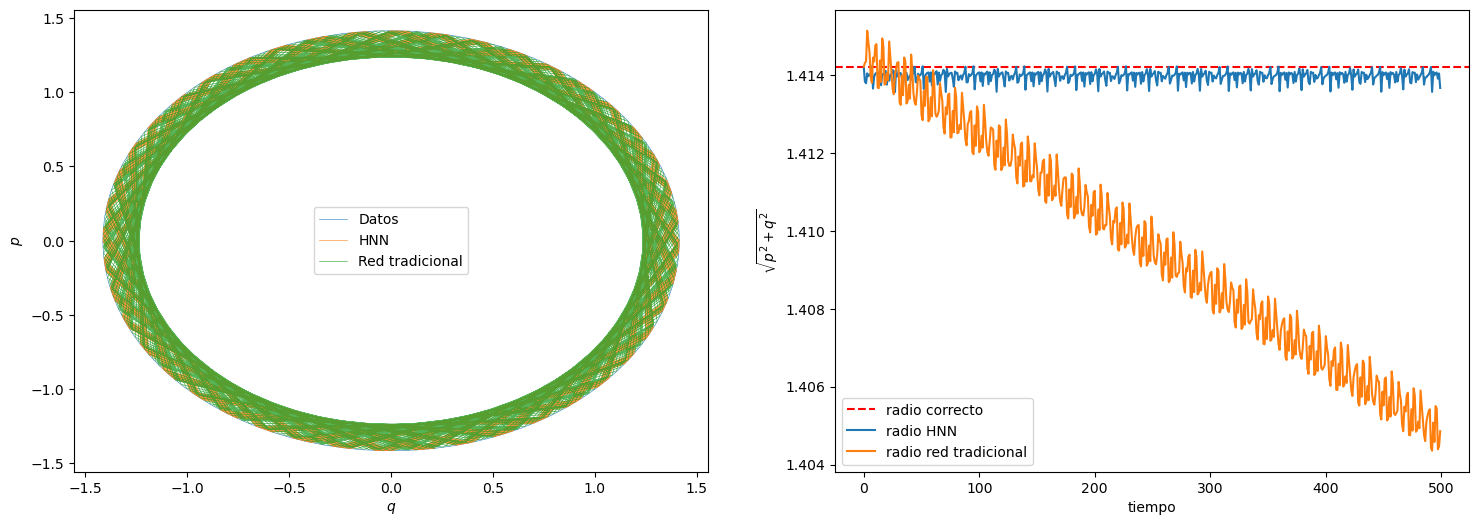

In [7]:
fig, ax = plt.subplots(1,2, figsize = (18,6))

ax[0].plot(*coords, lw = 0.5, label = "Datos", alpha = 0.8)
ax[0].plot(*y_hnn.T, lw = 0.5, label = "HNN", alpha = 0.8)
ax[0].plot(*y_baseline.T, lw = 0.5, label = "Red tradicional", alpha = 0.8)
ax[0].legend()
ax[0].set_xlabel("$q$")
ax[0].set_ylabel("$p$")

ax[1].axhline(np.sqrt(2), linestyle = "--", color = "red", label = "radio correcto")
ax[1].plot(np.abs(np.linalg.norm(y_hnn, axis=1)), label = "radio HNN")
ax[1].plot(np.abs(np.linalg.norm(y_baseline, axis=1)), label = "radio red tradicional")
ax[1].legend()
ax[1].set_xlabel("tiempo")
ax[1].set_ylabel(r'$\sqrt{p^2+q^2}$')


# Duffing

In [8]:
def duffing_H(q, p):
    return p**2 / 2 - q**2 / 2 + q**4 / 4


def dynamics_fn(t, y):
    q, p = y
    return [p, q - q**3]


def total_energy_np(states):
    q, p = states[:, 0], states[:, 1]
    return p**2 / 2 - q**2 / 2 + q**4 / 4

def generate_data(n_traj=1000, n_obs=100, q_range=(-1.5, 1.5),
                  p_range=(-1.5, 1.5), t_max=10, seed=42):
    """Generate Duffing oscillator trajectories on a grid of ICs.

    Returns:
        X:  (N, 2) array of (q, p) state vectors
        dX: (N, 2) array of (dq/dt, dp/dt)
    """
    rng = np.random.default_rng(seed)
    n_side = int(np.sqrt(n_traj))
    Q = np.linspace(q_range[0], q_range[1], n_side)
    P = np.linspace(p_range[0], p_range[1], n_side)

    t_eval = np.linspace(0, t_max, n_obs)

    coords_list = []
    derivs_list = []
    n_success = 0
    n_fail = 0

    for q0 in Q:
        for p0 in P:
            # Skip the unstable equilibrium at q=0, p=0
            if abs(q0) < 1e-6 and abs(p0) < 1e-6:
                n_fail += 1
                continue

            try:
                sol = solve_ivp(dynamics_fn, (0, t_max), [q0, p0],
                                t_eval=t_eval, method='RK45',
                                rtol=1e-10, atol=1e-10)
                if sol.status != 0:
                    n_fail += 1
                    continue
            except Exception:
                n_fail += 1
                continue

            states = sol.y.T  # (n_obs, 2)
            # Analytic derivatives
            dq = states[:, 1]                        # dq/dt = p
            dp = states[:, 0] - states[:, 0]**3      # dp/dt = q - q^3
            derivs = np.stack([dq, dp], axis=1)      # (n_obs, 2)

            coords_list.append(states)
            derivs_list.append(derivs)
            n_success += 1

    X = np.vstack(coords_list)
    dX = np.vstack(derivs_list)

    return X, dX, n_success

X, dX, n_success = generate_data()

In [9]:
X = torch.tensor(X, dtype=TTYPE)
dX = torch.tensor(dX, dtype=TTYPE)

indx = np.random.permutation(len(X))

train_indx = indx[:int(len(indx)*0.8)]
test_indx = indx[int(len(indx)*0.8):]

hnn_model = HNN(1, 1)
hnn_optim = torch.optim.Adam(hnn_model.parameters(), lr = 1e-3)

baseline_model = BaselineNN(1,1)
baseline_optim = torch.optim.Adam(baseline_model.parameters(), lr = 1e-3)


for step in range(2000):
    X = X.requires_grad_(True)
    hnn_optim.zero_grad()
    baseline_optim.zero_grad()
    hnn_L = hnn_loss(hnn_model, X[train_indx], dX[train_indx])
    baseline_L = baseline_loss(baseline_model, X[train_indx], dX[train_indx])
    hnn_L.backward()
    hnn_optim.step()
    baseline_L.backward()
    baseline_optim.step()
    print(f"{step}, HNN: {hnn_L.item()}, Baseline: {baseline_L.item()}")


0, HNN: 0.9254099726676941, Baseline: 0.9640501737594604
1, HNN: 0.8240910768508911, Baseline: 0.6101847290992737
2, HNN: 0.7311715483665466, Baseline: 0.4094793200492859
3, HNN: 0.6427098512649536, Baseline: 0.3469065725803375
4, HNN: 0.5610135793685913, Baseline: 0.38327693939208984
5, HNN: 0.4904429018497467, Baseline: 0.4320574402809143
6, HNN: 0.43393462896347046, Baseline: 0.43449655175209045
7, HNN: 0.3921765983104706, Baseline: 0.3991706967353821
8, HNN: 0.364980012178421, Baseline: 0.3581082224845886
9, HNN: 0.349592000246048, Baseline: 0.3351207971572876
10, HNN: 0.33999747037887573, Baseline: 0.336605429649353
11, HNN: 0.3304648697376251, Baseline: 0.35301870107650757
12, HNN: 0.31909921765327454, Baseline: 0.3682209551334381
13, HNN: 0.3094496726989746, Baseline: 0.3715299665927887
14, HNN: 0.3033912777900696, Baseline: 0.3624311685562134
15, HNN: 0.29809871315956116, Baseline: 0.34699538350105286
16, HNN: 0.2900504469871521, Baseline: 0.3325105905532837
17, HNN: 0.27831622

In [10]:
ics = [
    [1.0, 0.5],
    [0.5, 0.0],
    [-1.0, 0.5],
    [-0.5, 0.0],
    [0.0, 1.0],
    [1.5, 0.0],
    [0.0, 0.15]
]


def integrate_ground_truth(y0, t_span, n_points=500):
    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    sol = solve_ivp(dynamics_fn, t_span, y0, t_eval=t_eval,
                    method='RK45', rtol=1e-12, atol=1e-12)
    return sol.t, sol.y.T

def integrate_learned(model, y0, t_span, n_points=500, rtol=1e-9, atol=1e-9):
    h = model.half
    is_hnn = isinstance(model, HNN)

    def dydt(t, y_np):
        state = torch.tensor(y_np, dtype=torch.float32).unsqueeze(0)
        if is_hnn:
            state = state.requires_grad_(True)
            H = model.forward(state).sum()
            grad = torch.autograd.grad(H, state)[0][0]
            return torch.cat([grad[h:], -grad[:h]]).detach().numpy()
        else:
            with torch.no_grad():
                return model.forward(state)[0].numpy()

    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    sol = solve_ivp(dydt, t_span, y0, t_eval=t_eval, method='RK45',
                    rtol=rtol, atol=atol)
    return sol.t, sol.y.T

coords = []
hnn_coords = []
baseline_coords = []

for q,p in ics:
    _, y_tmp = integrate_ground_truth((q,p), (0,100))
    y_tmp = y_tmp.T
    coords.append(y_tmp)
    _, y_tmp = integrate_learned(hnn_model, (q,p), (0,100))
    hnn_coords.append(y_tmp.T)
    _, y_tmp = integrate_learned(baseline_model, (q,p), (0,100))
    baseline_coords.append(y_tmp.T)



Text(0.5, 1.0, 'Red neuronal tradicional')

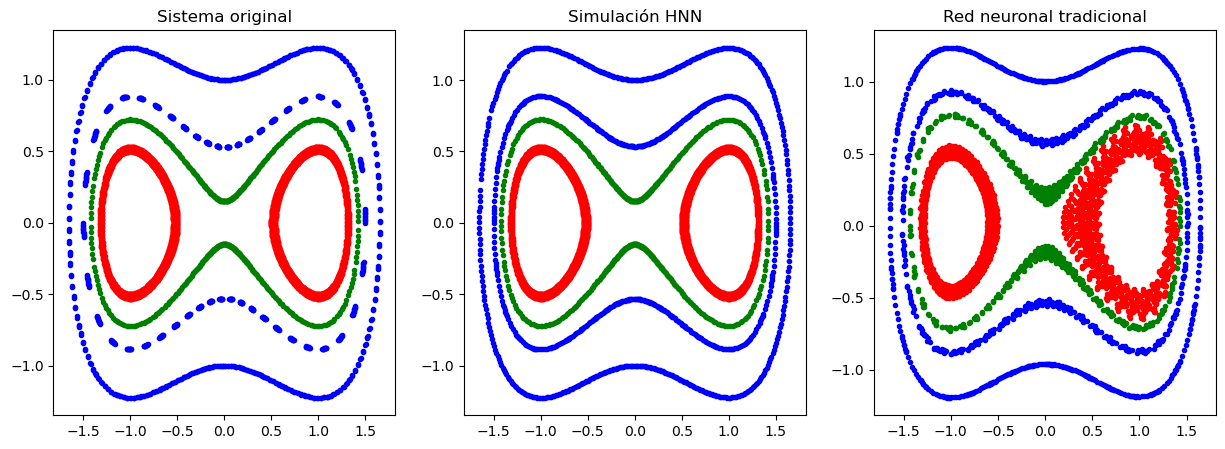

In [11]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].plot(*coords[0], "r.")
ax[0].plot(*coords[1], "r.")
ax[0].plot(*coords[2], "r.")
ax[0].plot(*coords[3], "r.")
ax[0].plot(*coords[4], "b.")
ax[0].plot(*coords[5], "b.")
ax[0].plot(*coords[6], "g.")
ax[0].set_title("Sistema original")

ax[1].plot(*hnn_coords[0], "r.")
ax[1].plot(*hnn_coords[1], "r.")
ax[1].plot(*hnn_coords[2], "r.")
ax[1].plot(*hnn_coords[3], "r.")
ax[1].plot(*hnn_coords[4], "b.")
ax[1].plot(*hnn_coords[5], "b.")
ax[1].plot(*hnn_coords[6], "g.")
ax[1].set_title("Simulación HNN")

ax[2].plot(*baseline_coords[0], "r.")
ax[2].plot(*baseline_coords[1], "r.")
ax[2].plot(*baseline_coords[2], "r.")
ax[2].plot(*baseline_coords[3], "r.")
ax[2].plot(*baseline_coords[4], "b.")
ax[2].plot(*baseline_coords[5], "b.")
ax[2].plot(*baseline_coords[6], "g.")
ax[2].set_title("Red neuronal tradicional")

Text(0, 0.5, '$p$')

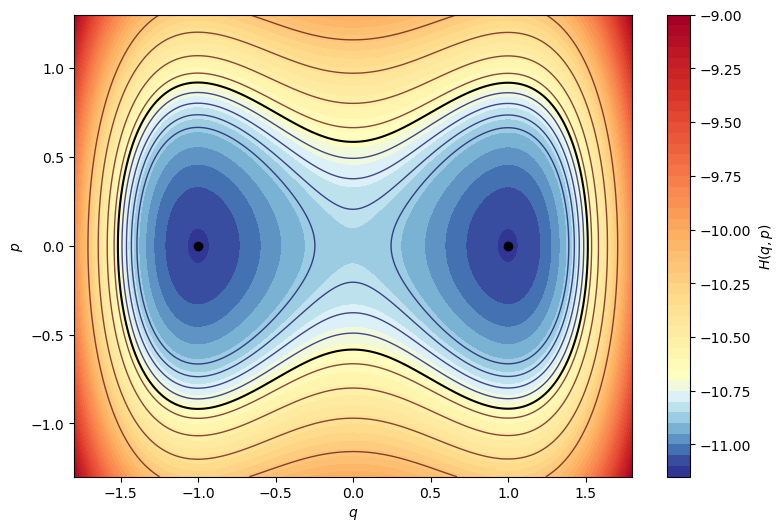

In [12]:
from matplotlib.colors import TwoSlopeNorm

hnn_model.eval()

plt.figure(figsize = (9,6))

Q = np.linspace(-1.8, 1.8, 1000)
P = np.linspace(-1.3, 1.3, 1000)

Q, P = np.meshgrid(Q, P)

sep_val = -10.6842

grid_tensor = torch.tensor(np.stack([Q.ravel(), P.ravel()], axis=1), dtype = TTYPE)

with torch.no_grad():
    H = hnn_model(grid_tensor)

norm = TwoSlopeNorm(vmin=H.min(), vcenter=sep_val, vmax=H.max())

H = H.reshape(Q.shape)
cont = plt.contourf(Q, P, H, levels=50, cmap='RdYlBu_r', norm = norm)
sep = plt.contour(Q,P,H, levels = [sep_val], colors = "black", linestyles = "solid")
plt.colorbar(cont, label='$H(q,p)$')


lib_levels = [x + sep_val for x in [-0.20, -0.15, -0.10, -0.05]]
cs_lib = plt.contour(Q, P, H, levels=lib_levels, colors='#1a1a6e',
                    linewidths=1.0, linestyles='solid', alpha=0.8)
cw_levels = [x + sep_val for x in [0.05, 0.15, 0.30, 0.50]]
cs_cw = plt.contour(Q, P, H, levels=cw_levels, colors='#6e1a1a',
                   linewidths=1.0, linestyles='solid', alpha=0.8)

plt.plot([1, -1], [0, 0], 'ko', markersize=6, zorder=5)        # stable at q=±1

plt.xlabel('$q$')
plt.ylabel('$p$')


# Henon-Heiles

In [13]:
LAMBDA = 1.0

def henon_heiles_H(q1, q2, p1, p2, lam=LAMBDA):
    """Hénon-Heiles Hamiltonian."""
    return (p1**2 + p2**2) / 2 + (q1**2 + q2**2) / 2 + lam * (q1**2 * q2 - q2**3 / 3)


def dynamics_fn(t, y):
    """Hamilton's equations for Hénon-Heiles.
    y = [q1, q2, p1, p2]"""
    q1, q2, p1, p2 = y
    dq1 = p1
    dq2 = p2
    dp1 = -q1 - 2 * LAMBDA * q1 * q2
    dp2 = -q2 - LAMBDA * (q1**2 - q2**2)
    return [dq1, dq2, dp1, dp2]

def total_energy_np(states):
    """Compute energy for (N, 4) state array."""
    q1, q2 = states[:, 0], states[:, 1]
    p1, p2 = states[:, 2], states[:, 3]
    return henon_heiles_H(q1, q2, p1, p2)


In [14]:
def random_ic(rng, energy_target, max_attempts=100):
    """Generate a random initial condition with approximately the given energy.
    Strategy: pick random q1, q2, p1, then solve for p2 from the energy constraint.
    H = p2^2/2 + rest = E  =>  p2 = sqrt(2*(E - rest))
    """
    for _ in range(max_attempts):
        # Random position in a reasonable range
        q1 = rng.uniform(-0.4, 0.4)
        q2 = rng.uniform(-0.4, 0.4)
        p1 = rng.uniform(-0.4, 0.4)

        rest = p1**2 / 2 + (q1**2 + q2**2) / 2 + LAMBDA * (q1**2 * q2 - q2**3 / 3)
        p2_sq = 2 * (energy_target - rest)

        if p2_sq > 0:
            p2 = rng.choice([-1, 1]) * np.sqrt(p2_sq)
            return np.array([q1, q2, p1, p2])

    return None


def generate_data(n_traj=500, n_obs=100, t_max=20, seed=42):
    rng = np.random.default_rng(seed)

    # Sample energies spanning regular to near-chaotic regimes
    # Escape energy for lambda=1 is E = 1/6 ≈ 0.1667
    energies = rng.uniform(0.02, 0.15, n_traj)

    t_eval = np.linspace(0, t_max, n_obs)

    coords_list = []
    derivs_list = []
    n_success = 0
    n_fail = 0

    for i in range(n_traj):
        y0 = random_ic(rng, energies[i])
        if y0 is None:
            n_fail += 1
            continue

        try:
            sol = solve_ivp(dynamics_fn, (0, t_max), y0,
                            t_eval=t_eval, method='RK45',
                            rtol=1e-10, atol=1e-10)
            if sol.status != 0:
                n_fail += 1
                continue
        except Exception:
            n_fail += 1
            continue

        states = sol.y.T  # (n_obs, 4)

        # Check for escaped trajectories (energy should be bounded)
        E = total_energy_np(states)
        if np.any(np.abs(E - E[0]) > 0.01):
            # Numerical instability or escape — skip
            n_fail += 1
            continue

        # Analytic derivatives
        q1, q2, p1, p2 = states[:, 0], states[:, 1], states[:, 2], states[:, 3]
        dq1 = p1
        dq2 = p2
        dp1 = -q1 - 2 * LAMBDA * q1 * q2
        dp2 = -q2 - LAMBDA * (q1**2 - q2**2)
        derivs = np.stack([dq1, dq2, dp1, dp2], axis=1)  # (n_obs, 4)

        coords_list.append(states)
        derivs_list.append(derivs)
        n_success += 1

    X = np.vstack(coords_list)
    dX = np.vstack(derivs_list)

    return X, dX, n_success


X, dX, n_success = generate_data()

In [15]:
X = torch.tensor(X, dtype=TTYPE)
dX = torch.tensor(dX, dtype=TTYPE)

indx = np.random.permutation(len(X))

train_indx = indx[:int(len(indx)*0.8)]
test_indx = indx[int(len(indx)*0.8):]

hnn_model = HNN(2, 1)
hnn_optim = torch.optim.Adam(hnn_model.parameters(), lr = 1e-3)

baseline_model = BaselineNN(2, 1)
baseline_optim = torch.optim.Adam(baseline_model.parameters(), lr = 1e-3)


for step in range(2000):
    X = X.requires_grad_(True)
    hnn_optim.zero_grad()
    baseline_optim.zero_grad()
    hnn_L = hnn_loss(hnn_model, X[train_indx], dX[train_indx])
    baseline_L = baseline_loss(baseline_model, X[train_indx], dX[train_indx])
    hnn_L.backward()
    hnn_optim.step()
    baseline_L.backward()
    baseline_optim.step()
    print(f"{step}, HNN: {hnn_L.item()}, Baseline: {baseline_L.item()}")


0, HNN: 0.044263020157814026, Baseline: 0.05153408274054527
1, HNN: 0.052255451679229736, Baseline: 0.04326678812503815
2, HNN: 0.0404050275683403, Baseline: 0.03107280284166336
3, HNN: 0.03685498610138893, Baseline: 0.01896519400179386
4, HNN: 0.03828038275241852, Baseline: 0.014399323612451553
5, HNN: 0.03575378283858299, Baseline: 0.012107758782804012
6, HNN: 0.031305134296417236, Baseline: 0.008452248759567738
7, HNN: 0.029254434630274773, Baseline: 0.005471574608236551
8, HNN: 0.029381372034549713, Baseline: 0.005605743266642094
9, HNN: 0.027441296726465225, Baseline: 0.007690258789807558
10, HNN: 0.02361118420958519, Baseline: 0.008399229496717453
11, HNN: 0.021090874448418617, Baseline: 0.007434182800352573
12, HNN: 0.020408859476447105, Baseline: 0.006788256112486124
13, HNN: 0.018628740683197975, Baseline: 0.007107064593583345
14, HNN: 0.015263145789504051, Baseline: 0.007044850382953882
15, HNN: 0.012976492755115032, Baseline: 0.005923377815634012
16, HNN: 0.01240125391632318

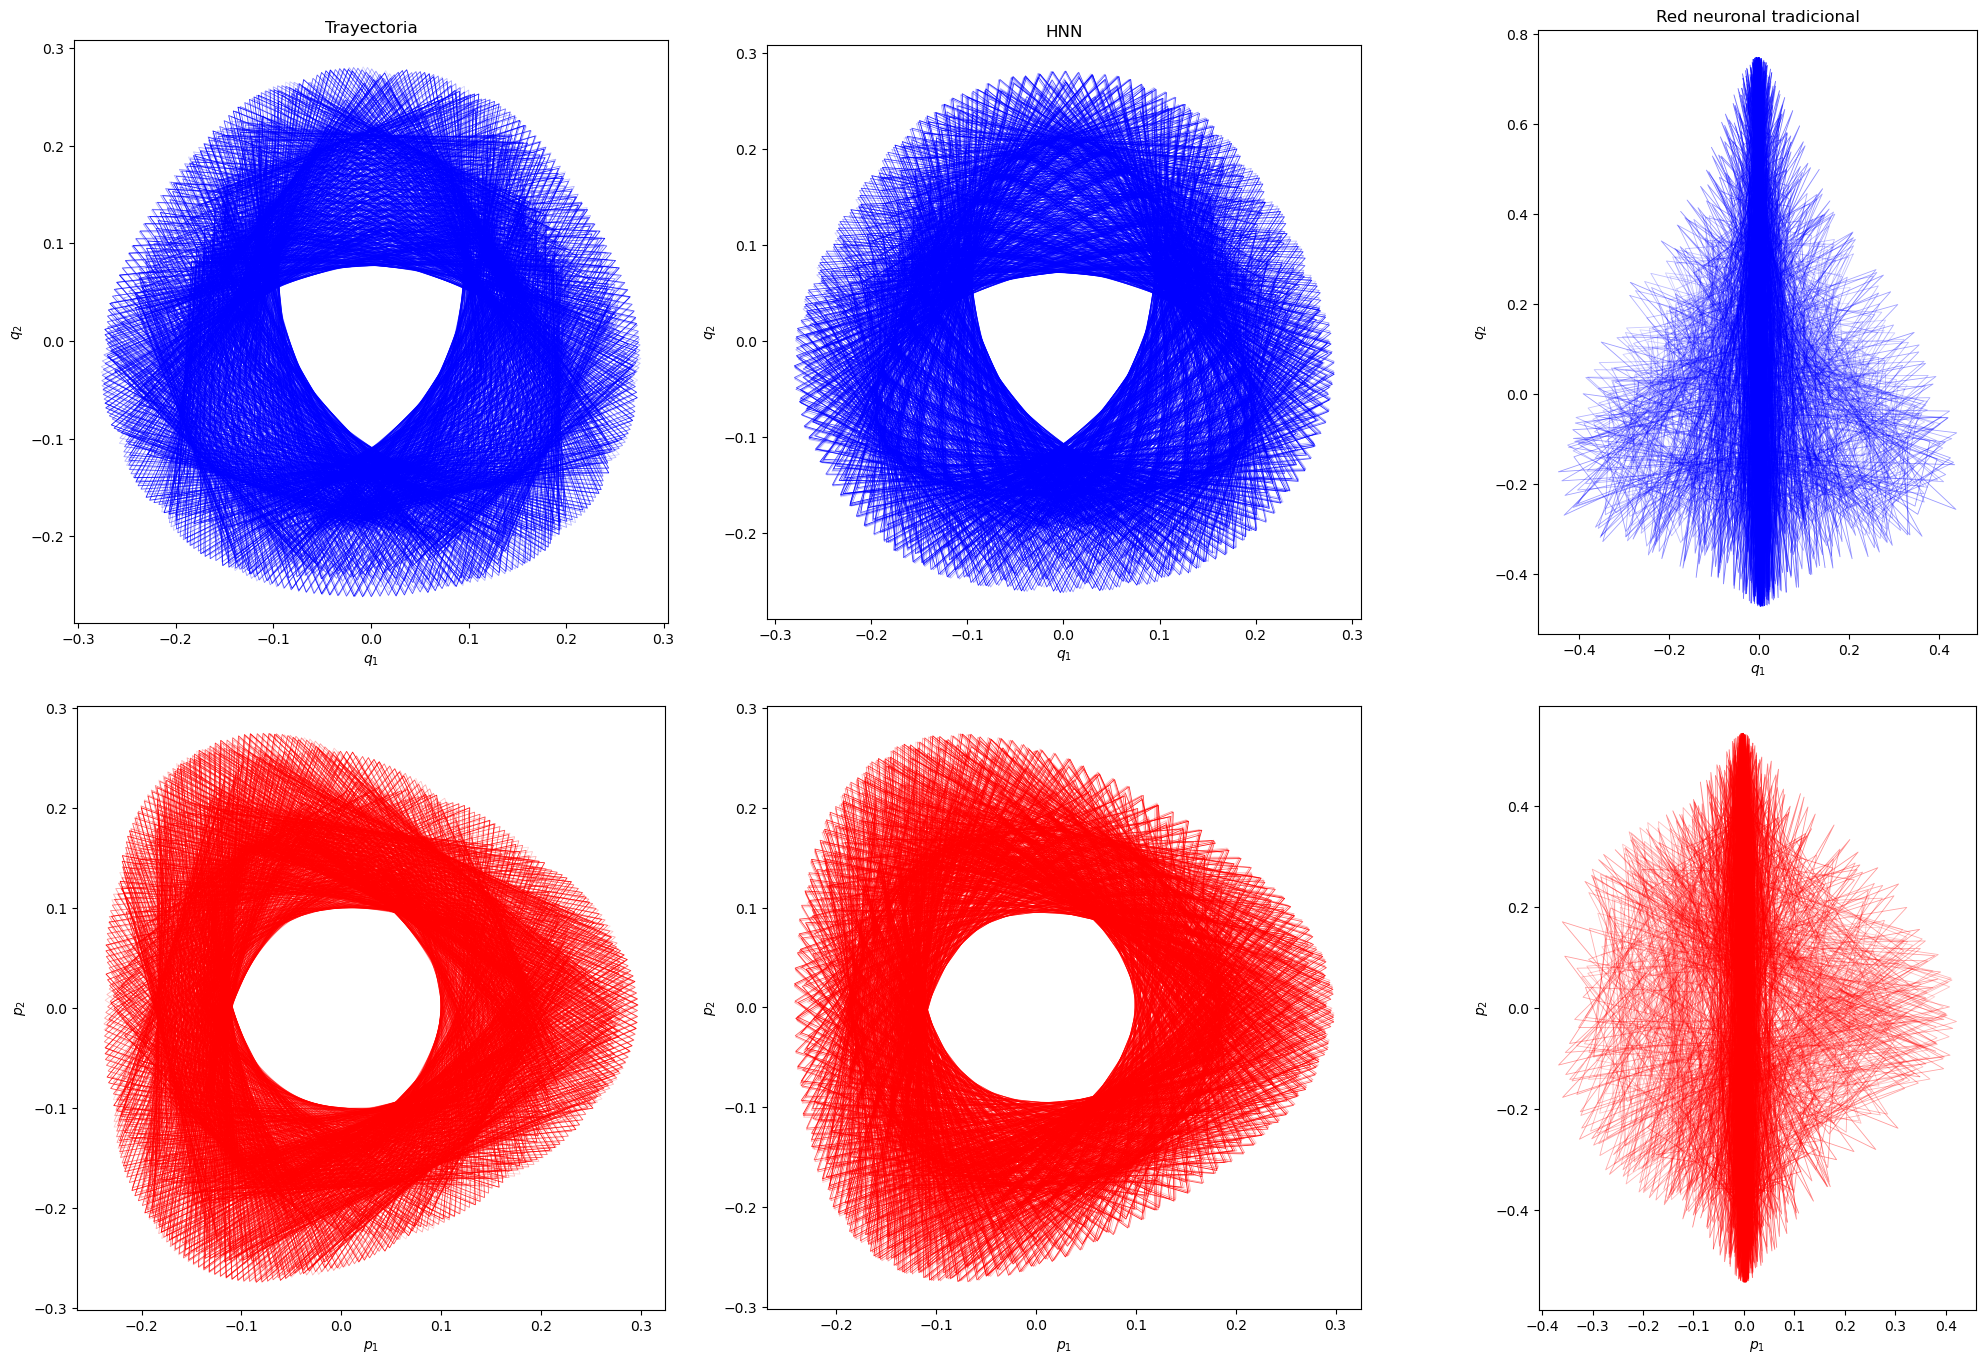

In [16]:
def plot_trajectories_2d(hnn_model, baseline_model):
    rng = np.random.default_rng(7)

    energies = [0.05]
    labels = ['Regular (E=0.05)']
    t_span = (0, 5000)
    n_pts = 3000

    titles = ['Trayectoria', 'HNN', 'Red neuronal tradicional']

    fig, axes = plt.subplots(2, 3, figsize=(21, 14))

    for e_idx, (E, elabel) in enumerate(zip(energies, labels)):
        y0 = random_ic(rng, E)
        if y0 is None:
            continue

        for col, title in enumerate(titles):
            if col == 0:
                _, states = integrate_ground_truth(y0, t_span, n_pts)
            elif col == 1:
                try:
                    _, states = integrate_learned(hnn_model, y0, t_span, n_pts)
                except Exception:
                    continue
            else:
                try:
                    _, states = integrate_learned(baseline_model, y0, t_span, n_pts)
                except Exception:
                    continue

            n = len(states)
            seg = max(1, n // 60)

            # Row 0: configuration space (q1, q2)
            ax = axes[0, col]
            ax.set_title(title)
            ax.set_xlabel('$q_1$')
            ax.set_ylabel('$q_2$')
            ax.set_aspect('equal')
            for i in range(0, n - seg, seg):
                alpha = 0.15 + 0.85 * (i / n)
                ax.plot(states[i:i+seg+1, 0], states[i:i+seg+1, 1],
                        '-', color="blue", lw=0.6, alpha=alpha)

            # Row 1: momentum space (p1, p2)
            ax = axes[1, col]
            ax.set_xlabel('$p_1$')
            ax.set_ylabel('$p_2$')
            ax.set_aspect('equal')
            for i in range(0, n - seg, seg):
                alpha = 0.15 + 0.85 * (i / n)
                ax.plot(states[i:i+seg+1, 2], states[i:i+seg+1, 3],
                        '-', color="red", lw=0.6, alpha=alpha)

    plt.tight_layout(pad=2.0)

plot_trajectories_2d(hnn_model, baseline_model)
